Входные данные, в будущем лучше грузить из файла

In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
# My library imports
from fluid import Fluid
from function_dp import vniigaz_vertical_one, vniigaz_vertical_two, vniigaz_inclined, vniigaz_horizontal
from function_dp import lyamda

In [5]:
# Структура импорта файлов для расчёта

# Импорт инклинометрии скважины
file_path_incl = 'include/incl_vertical.dev'  # Ввод пути инклинометрии скважины
with open(file_path_incl, 'r', encoding='utf-8') as inclinometry_file:
    well_data = pd.read_csv(inclinometry_file, comment='#', sep=r'\s+')

# Импорт данных PVT
file_path_pvt = 'include/PVT.inc'  # Ввод пути данных PVT
with open(file_path_pvt, 'r', encoding='utf-8') as pvt_file:
    pvt_data = pd.read_csv(pvt_file, comment='#', sep=r'\s+')

# Импорт фактических данных по исследованиям gki/gdi
file_path_incl_gdi = 'include/GDI.inc'  # Ввод пути фактических данных gki/gdi
with open(file_path_incl_gdi, 'r', encoding='utf-8') as gdi_data:
    gdi_data = pd.read_csv(gdi_data, comment='#', sep=r'\s+')

In [6]:
# Ввод исходных данных для расчёта

diameter = 0.1000     # м, диаметр трубы
sigma = 0.072         # Н/м, поверхностное натяжение
Rog_std = 0.67        # кг/м3, плотность газа ст. усл.
Row_std = 1000        # кг/м3, плотность воды ст. усл.
xa = 0.8858           # моль%, азота N2
xy = 0.0668           # моль%, диоксид углерода CO2
wellhead_temp = 300       # К, температура на устье
reservoir_temp = 350    # К, температура в пласте


In [7]:
# Создание объекта класса Fluid для хранения данных о флюиде
fluid = Fluid(Rog_std, xa, xy, pvt_data)

In [28]:
# Функция для расчёта забойного давления BHP по устьевому THP и расходу газа

def well_BHP(well_data: pd, fluid: Fluid, THP, Temp_THP, Temp_BHP, Qgas, WGR, diameter, delta0, sigma, density_liquid):
    """
    Параметры:
        well_data - DataFrame;
        fluid - class;
        THP [K];
        Qgas [ст. тыс.м3/сут];
        WGR [м3/м3];
        diamert [м];
        delta0 [мм];
        sigma [Н/м]
        density_liquid [кг/м3]
        # TODO: Добавить коэф. адаптации для lyamda
    Возвращает:
        BHP -> МПа
    """

    well_df = pd.DataFrame({
        'MD': well_data['MD'],
        'TVD': well_data['TVD'],
        'alfa': well_data['INCL'],
        'D': diameter, # TODO: сделать возможность задания конструкции по интервалу скважины
        'Dp_dz': np.nan,
        'P': np.nan
    })

    for idx in well_df.index:
        if idx == 0:
            well_df.loc[idx, 'P'] = THP
        if idx == len(well_df)-1:
            break

        temp_idx = Temp_THP + (Temp_BHP-Temp_THP)/well_df['TVD'].iloc[-1]*well_df.loc[idx, 'TVD'] # К
        density_gas_idx = fluid.get_ro(well_df.loc[idx, 'P'], temp_idx) # кг/м3
        velocity_liquid_idx = ((Qgas*1000/86400)*WGR) / (np.pi*well_df.loc[idx, 'D']**2/4) # м/с
        velocity_gas_idx = (Qgas*1000/86400) * fluid.get_fvf(well_df.loc[idx, 'P']) / (np.pi * well_df.loc[idx, 'D']**2 / 4) # м/с

        # TODO - добавить коэф. адаптации для lyamda
        lyamda_idx = lyamda(delta0=delta0, diameter=well_df.loc[idx, 'D'], 
              velocity_liquid=velocity_liquid_idx, velocity_gas=velocity_gas_idx, 
              density_liquid=density_liquid, density_gas=density_gas_idx, 
              sigma=sigma, viscosity_gas=fluid.get_viscosity(well_df.loc[idx, 'P']))

        # TODO - добавить возможность выбора формулы для расчёта dp/dz (one, two, inclined, horizontal)
        if well_df.loc[idx, 'alfa'] > 84:
            well_df.loc[idx, 'Dp_dz'] = vniigaz_horizontal(lyamda_idx, well_df.loc[idx, 'D'], well_df.loc[idx, 'alfa'],
                                                            velocity_liquid_idx, velocity_gas_idx, density_liquid,
                                                              density_gas_idx, well_df.loc[idx, 'P'],
                                                                sigma, ((Qgas*1000/86400)*WGR)) # Па/м
        else:
            well_df.loc[idx, 'Dp_dz'] = vniigaz_inclined(lyamda_idx, well_df.loc[idx, 'D'], well_df.loc[idx, 'alfa'],
                                                          velocity_liquid_idx, velocity_gas_idx, density_liquid,
                                                            density_gas_idx, well_df.loc[idx, 'P'],
                                                              sigma, ((Qgas*1000/86400)*WGR)) # Па/м

        well_df.loc[idx+1,'P'] = well_df.loc[idx,'P'] + well_df.loc[idx, 'Dp_dz'] * 10**-6 * (well_df.loc[idx+1, 'MD'] - well_df.loc[idx, 'MD']) # МПа

    return well_df['P'].iloc[-1] # МПа

In [34]:
# Функция для создания df с существующими исследованиями GDI и расчётными значениями

def adapt_gdi(GDI_data: pd, delta0: float, density_liquid: float):
        """
        Параметры:
            well_data - DataFrame;
            fluid - class;
            THP [K];
            Qgas [ст. тыс.м3/сут];
            WGR [м3/м3];
            diamert [м];
            delta0 [мм];
            sigma [Н/м]
            density_liquid [кг/м3]
            # TODO: Добавить коэф. адаптации для lyamda
        Возвращает:
            BHP -> МПа
        """
        df_data = pd.DataFrame({
        'THP': GDI_data['THP']/10, # перевод в МПа
        'FLO': GDI_data['FLO']/1000, # перевод в ст. тыс.м3/сут
        'WGR': GDI_data['WGR'], # м3/м3
        'BHP': GDI_data['BHP']/10, # перевод в МПа

        'BHP_calc': np.nan,
        'dp_calc': np.nan,
        'd_bhp': np.nan
        })

        for idx in df_data.index:
                df_data.loc[idx,'BHP_calc'] = well_BHP(well_data, fluid, 
                                                       df_data.loc[idx, 'THP'], wellhead_temp, reservoir_temp, 
                                                       df_data.loc[idx, 'FLO'], df_data.loc[idx, 'WGR'], diameter, 
                                                       delta0, 0.072, density_liquid)
                
                df_data.loc[idx,'dp_calc'] = df_data.loc[idx, 'BHP_calc'] - df_data.loc[idx, 'THP']

                df_data.loc[idx,'d_bhp'] = df_data.loc[idx,'BHP_calc'] - df_data.loc[idx,'BHP']

        r2 = r2_score(df_data['BHP'], df_data['BHP_calc'])
    
        return df_data

# функция для подстановки параметров
def objective(params):
    delta0, density_liquid = params

    # Ограничения (важно!)
    if delta0 <= 0 or density_liquid <= 0:
        return 1e6

    df = adapt_gdi(gdi_data, delta0, density_liquid)

    mse = mean_squared_error(df['BHP'], df['BHP_calc'])
    return mse  # минимизируем ошибку

In [11]:
# Вызов функции адаптации
initial_guess = [0.02, 900]

result = minimize(
    objective,
    initial_guess,
    method='Nelder-Mead'
)

opt_delta0, opt_density = result.x

print(f'Оптимальные параметры:')
print(f'delta0 = {opt_delta0}')
print(f'density_liquid = {opt_density}')

Оптимальные параметры:
delta0 = 4.003116057780532e-12
density_liquid = 860.9871180366798


In [12]:
# delta0 = 0.00001
delta0 = 4.003116057780532e-12
# density_liquid = 2866.9854877120365
density_liquid = 860.9871180366798
adapt_gdi(gdi_data, delta0, density_liquid)

,THP,FLO,WGR,BHP,BHP_calc,dp_calc,d_bhp
0,3.1,127.0,0.000032,3.951580,3.574410,0.474410,-0.377170
1,0.2,509.0,0.000055,2.933329,4.740171,4.540171,1.806842
2,1.7,193.0,0.000081,2.420747,2.726731,1.026731,0.305983
3,5.4,241.0,0.000641,7.943172,7.793880,2.393880,-0.149293
4,11.8,365.0,0.000003,12.945381,13.162980,1.362980,0.217599
5,5.4,586.0,0.000097,7.208953,8.157712,2.757712,0.948759
6,20.0,260.0,0.000020,23.100210,21.984718,1.984718,-1.115492


In [ ]:
# FIXME: Привести в порядок, дописать код для полноценого создания VFP

def generate_vfp_table(q_gas_list, wgr_list, thp_list,
                       well_data, fluid,
                       Temp_THP, Temp_BHP,
                       diameter, delta0, sigma, density_liquid):

    rows = []

    # ВАЖНО: порядок как в VFP (WGR -> THP)
    for i_wgr, wgr in enumerate(wgr_list, start=1):
        for i_thp, thp in enumerate(thp_list, start=1):

            row = {
                'THP_i': i_thp,
                'WGR_i': i_wgr,
                'GFR_i': 1,
                'ALQ_i': 1,
            }

            # считаем BHP для каждого расхода газа
            for i_q, q in enumerate(q_gas_list, start=1):
                bhp = well_BHP(
                    well_data,
                    fluid,
                    thp,
                    Temp_THP,
                    Temp_BHP,
                    q,
                    wgr,
                    diameter,
                    delta0,
                    sigma,
                    density_liquid
                )

                row[f'BHP_q{i_q}'] = bhp # МПа

            rows.append(row)

    df = pd.DataFrame(rows)
    return df

In [14]:
q_gas_list = [10, 30, 50, 60, 100, 200, 300, 400, 600, 1000]  # ст. тыс.м3/сут
wgr_list = [0.0001, 0.00001, 0.000001, 0]  # м3/ м3
thp_list = [0.5, 1, 3, 5, 7, 10, 15, 25]  # МПа

vfp_table = generate_vfp_table(
    q_gas_list=q_gas_list,  # ст. тыс.м3/сут
    wgr_list=wgr_list,  # м3/ м3
    thp_list=thp_list,  # МПа
    well_data=well_data,
    fluid=fluid,
    Temp_THP=wellhead_temp,
    Temp_BHP=reservoir_temp,
    diameter=diameter,
    delta0=delta0,
    sigma=sigma,
    density_liquid=density_liquid)

In [15]:
vfp_table

,THP_i,WGR_i,GFR_i,ALQ_i,BHP_q1,BHP_q2,BHP_q3,BHP_q4,BHP_q5,BHP_q6,BHP_q7,BHP_q8,BHP_q9,BHP_q10
0,1,1,1,1,9.874421,1.180232,0.792389,0.815967,1.192937,2.137990,3.024063,3.875066,5.512711,8.665406
1,2,1,1,1,10.848720,3.038737,1.480254,1.400152,1.506951,2.347092,3.175827,3.988789,5.571987,8.616462
2,3,1,1,1,13.416506,9.083885,4.921343,4.265503,3.684933,3.927859,4.513163,5.138383,6.456275,9.191116
3,4,1,1,1,15.695825,12.805631,8.574374,7.423236,6.075449,5.939508,6.349945,6.839033,7.914998,10.298708
4,5,1,1,1,17.919907,15.782156,11.984273,10.590174,8.535710,8.131156,8.350507,8.756298,9.661082,11.740638
5,6,1,1,1,21.219781,19.709740,16.599020,15.138417,12.300317,11.449877,11.508638,11.798886,12.539325,14.278383
6,7,1,1,1,26.683228,25.698111,23.424712,22.123280,18.644518,17.030079,16.966650,17.061796,17.632784,19.021141
7,8,1,1,1,37.548992,37.001617,35.631915,34.707559,31.188844,28.301664,27.947918,27.952612,28.182110,29.238264
8,1,2,1,1,9.652829,0.810340,0.641529,0.729588,1.106336,1.980307,2.804350,3.598453,5.131904,8.096870
9,2,2,1,1,10.704106,2.136870,1.227983,1.187632,1.408076,2.175496,2.943978,3.702334,5.185621,8.052305


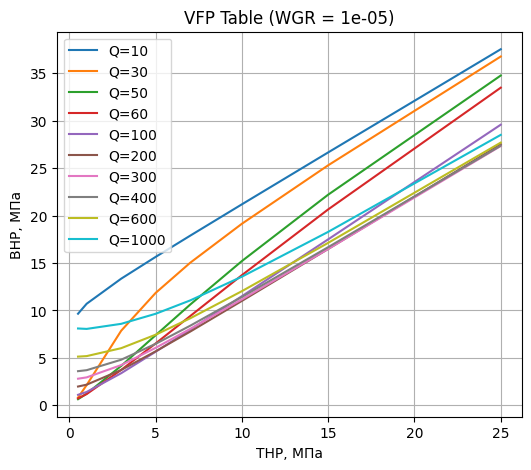

In [16]:
WGR_tabl = 2  # ← De

n_thp = len(thp_list)

start = (WGR_tabl - 1) * n_thp
end = start + n_thp

df_slice = vfp_table.iloc[start:end]

plt.figure(figsize=(6, 5))

for i, q in enumerate(q_gas_list, start=1):
    plt.plot(
        thp_list,
        df_slice[f'BHP_q{i}'],
        label=f'Q={q}'
    )

plt.xlabel('THP, МПа')
plt.ylabel('BHP, МПа')
plt.title(f'VFP Table (WGR = {wgr_list[WGR_tabl-1]})')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Расчёт UDT таблиц
bhp_test = 18
wgr_test = 1e-5
Q_gas_list = range(10,200,10)
thp_graph = []

# for q in Q_gas_list:
#     print(q)

In [50]:
def well_THP(well_data: pd, fluid: Fluid, BHP, Temp_THP, Temp_BHP, Qgas, WGR, diameter, delta0, sigma, density_liquid):
    """
    Расчёт устьевого давления THP по известному забойному давлению BHP.
    
    Параметры:
        well_data - DataFrame;
        fluid - class;
        BHP [МПа] - забойное давление;
        Temp_THP [K] - температура на устье;
        Temp_BHP [K] - температура на забое;
        Qgas [ст. тыс.м3/сут] - дебит газа;
        WGR [м3/м3] - водогазовый фактор;
        diameter [м] - диаметр трубы;
        delta0 [мм] - шероховатость;
        sigma [Н/м] - поверхностное натяжение;
        density_liquid [кг/м3] - плотность жидкости;
    
    Возвращает:
        THP -> МПа (устьевое давление)
    """
    
    well_df = pd.DataFrame({
        'MD': well_data['MD'],
        'TVD': well_data['TVD'],
        'alfa': well_data['INCL'],
        'D': diameter,
        'Dp_dz': np.nan,
        'P': np.nan
    })
    
    # Начинаем с забоя (последняя точка)
    last_idx = len(well_df) - 1
    well_df.loc[last_idx, 'P'] = BHP
    
    # Идём от забоя к устью (снизу вверх)
    for idx in range(last_idx, 0, -1):
        # Текущее давление (на забое или в нижней точке)
        pressure_current = well_df.loc[idx, 'P']
        
        # Температура в текущей точке
        temp_idx = Temp_THP + (Temp_BHP - Temp_THP) / well_df['TVD'].iloc[-1] * well_df.loc[idx, 'TVD']
        
        # Свойства газа при текущем давлении
        density_gas_idx = fluid.get_ro(pressure_current, temp_idx)  # кг/м3
        velocity_liquid_idx = ((Qgas * 1000 / 86400) * WGR) / (np.pi * well_df.loc[idx, 'D']**2 / 4)  # м/с
        velocity_gas_idx = (Qgas * 1000 / 86400) * fluid.get_fvf(pressure_current) / (np.pi * well_df.loc[idx, 'D']**2 / 4)  # м/с
        
        # Коэффициент трения
        lyamda_idx = lyamda(
            delta0=delta0,
            diameter=well_df.loc[idx, 'D'],
            velocity_liquid=velocity_liquid_idx,
            velocity_gas=velocity_gas_idx,
            density_liquid=density_liquid,
            density_gas=density_gas_idx,
            sigma=sigma,
            viscosity_gas=fluid.get_viscosity(pressure_current)
        )
        
        # Расчёт градиента давления (положительный при движении снизу вверх)
        if well_df.loc[idx, 'alfa'] > 84:
            dp_dz = vniigaz_horizontal(
                lyamda_idx, well_df.loc[idx, 'D'], well_df.loc[idx, 'alfa'],
                velocity_liquid_idx, velocity_gas_idx, density_liquid,
                density_gas_idx, pressure_current, sigma,
                ((Qgas * 1000 / 86400) * WGR)
            )  # Па/м
        else:
            dp_dz = vniigaz_inclined(
                lyamda_idx, well_df.loc[idx, 'D'], well_df.loc[idx, 'alfa'],
                velocity_liquid_idx, velocity_gas_idx, density_liquid,
                density_gas_idx, pressure_current, sigma,
                ((Qgas * 1000 / 86400) * WGR)
            )  # Па/м
        
        well_df.loc[idx, 'Dp_dz'] = dp_dz
        
        # Переход к следующей точке (выше по стволу) - ВЫЧИТАЕМ градиент
        delta_MD = well_df.loc[idx, 'MD'] - well_df.loc[idx - 1, 'MD']
        pressure_next = pressure_current - (dp_dz * delta_MD) / 1e6  # Па -> МПа
        
        well_df.loc[idx - 1, 'P'] = pressure_next
        
        # Проверка на отрицательное давление
        if pressure_next <= 0:
            print(f"Предупреждение: отрицательное давление на глубине {well_df.loc[idx - 1, 'MD']:.0f} м")
            break
    
    # Возвращаем устьевое давление (первая точка)
    return well_df.loc[0, 'P']  # МПа

In [81]:
def check_reversibility(well_data, fluid, BHP_input, Temp_THP, Temp_BHP, Qgas, WGR, diameter, delta0, sigma, density_liquid):
    """
    Проверка обратимости функций well_BHP и well_THP.
    
    Возвращает:
    - THP, рассчитанное из BHP
    - BHP, рассчитанное обратно из THP
    - Исходное BHP
    - Ошибку
    """
    
    # Шаг 1: BHP -> THP
    THP_calc = well_THP(well_data, fluid, BHP_input, Temp_THP, Temp_BHP, Qgas, WGR, diameter, delta0, sigma, density_liquid)
    
    # Шаг 2: THP -> BHP (обратно)
    BHP_calc = well_BHP(well_data, fluid, THP_calc, Temp_THP, Temp_BHP, Qgas, WGR, diameter, delta0, sigma, density_liquid)
    
    print(f'BHP: {BHP_input}, THP: {THP_calc}, BHP: {BHP_calc}')

    # Ошибка
    error = abs(BHP_calc - BHP_input)
    rel_error = (error / BHP_input) * 100 if BHP_input != 0 else 0
    
    print(f"BHP (вход) = {BHP_input:.6f} МПа")
    print(f"THP (расч)  = {THP_calc:.6f} МПа")
    print(f"BHP (выход) = {BHP_calc:.6f} МПа")
    print(f"Ошибка = {error:.6f} МПа ({rel_error:.4f}%)")
    
    return THP_calc, BHP_calc, error


# Быстрая проверка
# THP_from_BHP, BHP_from_THP, error = check_reversibility(
#     well_data=well_data,
#     fluid=fluid,
#     BHP_input=9.000,
#     Temp_THP=293,
#     Temp_BHP=310,
#     Qgas=1000,
#     WGR=1e-5,
#     diameter=0.1,
#     delta0=0.012,
#     sigma=0.072,
#     density_liquid=1000
# )

# Или одной строкой:
THP_calc = well_THP(well_data, fluid, 10.000, 293, 310, 100, 1e-5, 0.1, 0.0012, 0.072, 1000)
BHP_calc = well_BHP(well_data, fluid, THP_calc, 293, 310, 100, 1e-5, 0.1, 0.0012, 0.072, 1000)
print(10.000, THP_calc, BHP_calc)
print(f"Ошибка: {abs(BHP_calc - 10.000):.6f} МПа")

10.0 8.509965590777137 9.991589330590868
Ошибка: 0.008411 МПа


In [ ]:
# ============================================================
# ============================================================
# ======= ---- Прошлый код для расчёта ---- ==================
# ============================================================
# ============================================================
# ============================================================

In [ ]:
# Прошлый блок ипорта исходных данных для расчёта
# Well properties 
# Download inclinometry data
file_path_incl = 'include/incl_17.dev'  # Update this path to match your actual file location
with open(file_path_incl, 'r', encoding='utf-8') as inclinometry_file:
    well_data = pd.read_csv(inclinometry_file, comment='#', sep=r'\s+')

# Download inclinometry data_horizontal
file_path_incl_horizontal = 'include/incl_10102.dev'  # Update this path to match your actual file location
with open(file_path_incl_horizontal, 'r', encoding='utf-8') as inclinometry_file_horizontal:
    well_data_hor = pd.read_csv(inclinometry_file_horizontal, comment='#', sep=r'\s+')

# Download inclinometry data full vertical well
file_path_incl_horizontal = 'include/incl_vertical.dev'  # Update this path to match your actual file location
with open(file_path_incl_horizontal, 'r', encoding='utf-8') as inclinometry_file_vert:
    well_data_vert = pd.read_csv(inclinometry_file_vert, comment='#', sep=r'\s+')

# Download GDI
file_path_incl_GDI = 'include/GDI.inc'  # Update this path to match your actual file location
with open(file_path_incl_GDI, 'r', encoding='utf-8') as GDI_data:
    GDI_data = pd.read_csv(GDI_data, comment='#', sep=r'\s+')

# Gas properties
# Download PVT data
file_path_pvt = 'include/PVT.inc'  # Update this path to match your actual file location
with open(file_path_pvt, 'r', encoding='utf-8') as pvt_file:
    pvt_data = pd.read_csv(pvt_file, comment='#', sep=r'\s+')

# Test fuid properties
Ro_gas_std = 0.6799
xa = 0.8858
xy = 0.0668
fluid = Fluid(Ro_gas_std, xa, xy, pvt_data)

In [ ]:
# Блок тестирования функций расчёта
# lyamda=0.0140 # Больше не использовать так как lyambda теперь это функция
diameter=0.1000
alfa=45
v=1.95E-03
u=5.643
Ro_water=1000.00
Ro_gas=19.24764133
pressure=2.896463361
sigma=0.072
q_liquid=1.52778E-05
q_gas=1.273148148
delta_0 = 0.0078 # шероховатость трубы в мм

# # -- Тестовые расчёты функции ВНИИГАЗ
# a parametrs for horizontal:
# idx = 465
# alfa = well_propertis.loc[idx, 'alfa']
# # q_liquid = 0.000138889
# q_liquid = ((Q_gas_std*1000/86400)*wgr)
# diameter = 0.1
# v = well_propertis.loc[idx, 'v']
# u = well_propertis.loc[idx, 'u']
# Ro_gas = well_propertis.loc[idx, 'Ro_gas']
# q_gas = well_propertis.loc[idx, 'Qgas_pt']
# print(alfa)

func_lyambda = lyamda(delta0=0.0078, diameter=0.1, 
                      velocity_liquid=0.00194523, velocity_gas=5.643, 
                      density_liquid=1000, density_gas=19.24764133, 
                      sigma=0.072, viscosity_gas=0.000012)
print("lyamda:", func_lyambda)

horizont = vniigaz_horizontal(0.014, diameter, alfa, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
print("dp_dz from vniigaz_horizont:", horizont)

# inclined = vniigaz_inclined(0.014, diameter, alfa, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_inclined:", inclined)

# vertical = vniigaz_vertical_one(0.014, diameter, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_vertical_one:", vertical)

# vertical_two = vniigaz_vertical_two(0.014, diameter, v, u, Ro_water, Ro_gas, pressure, sigma, q_liquid)
# print("dp_dz from vniigaz_two:", vertical_two)


lyamda: 0.013243343183010918
dp_dz from vniigaz_horizont: 644.4243111467007


In [8]:
# Standard conditions
Pstd = 101325 #Pa
Tstd = 273.15 + 20 #K

# Fluid
Ro_gas_std = 0.67 # кг/м3
Ro_water_std = 1000 # кг/м3
sigma = 0.072 # Н/м, поверхностное натяжение

# Reservoir
permability = 10*10**-12 # м2
pay_thickness = 10 # м

reservoir_temp = 305.15 # K
wellhead_temp = 293.15 # K
reservoir_pressure = 4.65 # МПа

# Data for gas-liquid flow
Q_gas_std = 100 # тыс.м3/сутки
diameter = 0.1 # м, диаметр трубы
delta0 = 0.0078 # мм, шероховатость трубы
# wgr = 12*10**-5 # м3/м3, водогазовый фактор
wgr = 1e-5 # м3/м3, водогазовый фактор

In [10]:
# Расчёт градиента давления (dp/dx) от забоя до устья

well_propertis = pd.DataFrame({
    'MD': well_data_vert['MD'],
    'TVD': well_data_vert['TVD'],
    'alfa': well_data_vert['INCL'],
    'Diameter': diameter,
    'T': np.nan,
    'z': np.nan,
    'Ro_gas': np.nan,
    'Qgas_pt': np.nan,
    'Dp_dz': np.nan,
})

for idx in well_propertis.index[::-1]:

    # Заполнение параметра Т в зависимости от глубины скважины
    if idx == 0:
        well_propertis.loc[idx, 'T'] = wellhead_temp
    elif idx == len(well_propertis)-1:
        well_propertis.loc[idx, 'T'] = reservoir_temp
    else:
        well_propertis.loc[idx, 'T'] = reservoir_temp - (reservoir_temp - wellhead_temp) * (well_propertis.loc[idx, 'TVD'] / well_propertis['TVD'].iloc[-1])

    # Заполнение параметра Pi в зависимости от глубины скважины
    if idx == len(well_propertis)-1:
        well_propertis.loc[idx, 'Pi'] = reservoir_pressure

    tempreture = well_propertis.loc[idx, 'T'] # К
    pressure = well_propertis.loc[idx, 'Pi'] # МПа

    # Расчёт z
    if not pd.isna(well_propertis.loc[idx, 'Pi']):
        well_propertis.loc[idx, 'z'] = fluid.get_Z(pressure, tempreture)
        well_propertis.loc[idx, 'Ro_gas'] = fluid.get_ro(well_propertis.loc[idx, 'Pi'], well_propertis.loc[idx, 'T'])
        well_propertis.loc[idx, 'u'] = (Q_gas_std*1000/86400) * Ro_gas_std / well_propertis.loc[idx, 'Ro_gas'] / (np.pi*well_propertis.loc[idx, 'Diameter']**2/4)
        well_propertis.loc[idx, 'v'] = ((Q_gas_std*1000/86400)*wgr)/(np.pi*well_propertis.loc[idx, 'Diameter']**2/4)
        well_propertis.loc[idx, 'Qgas_pt'] = (Q_gas_std*1000/86400) * fluid.get_Bg(pressure, tempreture)
        func_lyambda = lyamda(delta0=delta0, diameter=well_propertis.loc[idx, 'Diameter'], 
                      velocity_liquid=well_propertis.loc[idx, 'v'], velocity_gas=well_propertis.loc[idx, 'u'], 
                      density_liquid=1000, density_gas=well_propertis.loc[idx, 'Ro_gas'], 
                      sigma=0.072, viscosity_gas= fluid.get_viscosity(well_propertis.loc[idx, 'Pi']))
        if well_propertis.loc[idx, 'alfa'] < 84:
            well_propertis.loc[idx, 'Dp_dz'] = vniigaz_inclined(func_lyambda, diameter, well_propertis.loc[idx, 'alfa'], well_propertis.loc[idx, 'v'], well_propertis.loc[idx, 'u'], Ro_water_std, well_propertis.loc[idx, 'Ro_gas'], pressure, sigma, ((Q_gas_std*1000/86400)*wgr))
        else:
            well_propertis.loc[idx, 'Dp_dz'] = vniigaz_horizontal(func_lyambda, diameter, well_propertis.loc[idx, 'alfa'], well_propertis.loc[idx, 'v'], well_propertis.loc[idx, 'u'], Ro_water_std, well_propertis.loc[idx, 'Ro_gas'], pressure, sigma, ((Q_gas_std*1000/86400)*wgr))
        if idx > 0:
            well_propertis.loc[idx, 'Pi1'] = well_propertis.loc[idx, 'Pi'] - (well_propertis.loc[idx, 'Dp_dz'] * (well_propertis.loc[idx, 'MD'] - well_propertis.loc[idx-1, 'MD']))*10**-6     
            well_propertis.loc[idx-1, 'Pi'] = well_propertis.loc[idx, 'Pi1']

In [ ]:
detlta0 = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001, 0.00000001, 0.000000001, 0.0000000001]
q_gas = 150
WGR = 1e-5
THP_list = [5, 10, 15, 30, 50, 70]
BHP_list = {f"BHP_{i}": [] for i in range(1, len(detlta0)+1)}

for i, delta in enumerate(BHP_list):
    BHP_list[f"BHP_{i+1}"] = []
    for THP in THP_list:
        bhp = well_BHP(well_data_vert, fluid, THP, wellhead_temp, reservoir_temp, q_gas, WGR, diameter, detlta0[i], 0.072, density_liquid)*10
        BHP_list[f"BHP_{i+1}"].append(bhp)



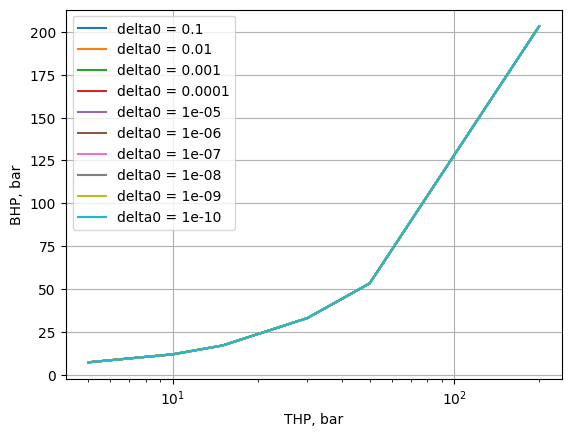

In [76]:
detlta0 = [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001,
           0.0000001, 0.00000001, 0.000000001, 0.0000000001]

q_gas = 550
WGR = 1e-5
THP_list = [5, 10, 15, 30, 50, 200]

BHP_list = {f"BHP_{i+1}": [] for i in range(len(detlta0))}

# расчет
for i, delta in enumerate(detlta0):
    for THP in THP_list:
        bhp = well_BHP(
            well_data_vert,
            fluid,
            THP,
            wellhead_temp,
            reservoir_temp,
            q_gas,
            WGR,
            diameter,
            delta,   # ← теперь правильно
            0.072,
            density_liquid
        )  # МПа → бар

        BHP_list[f"BHP_{i+1}"].append(bhp)

# график
for i, delta in enumerate(detlta0):
    plt.plot(
        THP_list,
        BHP_list[f"BHP_{i+1}"],
        label=f'delta0 = {delta}'
    )

plt.xlabel('THP, bar')
plt.ylabel('BHP, bar')
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()


In [13]:
q_gas_list = [50, 100, 150, 250, 400, 600]
wgr_list = [0, 1e-06, 1e-05, 1e-04]
thp_list = [1, 2, 5, 10, 15, 20]


In [15]:
vfp_table = generate_vfp_table(q_gas_list, wgr_list, thp_list, well_data_vert, fluid, 293, 310, 0.1, 0.0114, 0.072, 1000)

In [16]:
vfp_table.to_csv('vfp_table')